# Toy example to check KL div loss

In [247]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE

from nnfabrik.utility.nn_helpers import set_random_seed


seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 5
torch.cuda.set_device(f"cuda:{cuda_number}")
device = f'cuda:{cuda_number}'

In [248]:
cluster_number=5
alpha=1.0
dec_starting_epoch=5
dec_warumup_epoch=10
kmeans_init=20
base_multiplier=4e3
subsamples=2000
exponent=1.5
data_spread = 5

/tmp/ipykernel_2109126/926429570.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", (num_clusters))  # Define colors for clusters


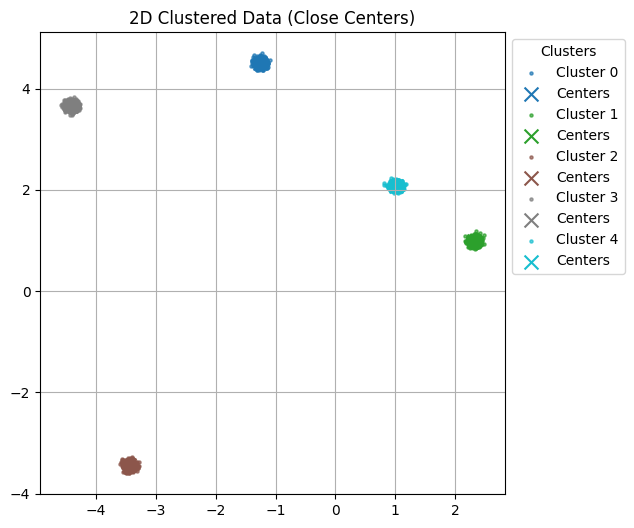

In [249]:
# Number of clusters and points per cluster
np.random.seed(seed)
num_clusters = cluster_number
points_per_cluster = 1000

# Generate cluster centers close to each other (distance ≈ 0.21)
base_center = np.array([0, 0])
cluster_centers = [base_center + np.random.uniform(-data_spread, data_spread, size=2) for _ in range(num_clusters)]

# Generate points around each cluster center
cluster_std = 0.05  # Small standard deviation to keep clusters tight
data = []
labels = []


for i, center in enumerate(cluster_centers):
    cluster_points = np.random.normal(loc=center, scale=cluster_std, size=(points_per_cluster, 2))
    data.append(cluster_points)
    labels.extend([i] * points_per_cluster)

data = np.vstack(data)
labels = np.array(labels)

colors = plt.cm.get_cmap("tab10", (num_clusters))  # Define colors for clusters
color_map = {label: colors(i) for i, label in enumerate(range(num_clusters))}

plt.figure(figsize=(6, 6))
for i in range(num_clusters):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], label=f"Cluster {i}", alpha=0.7, s=5, c=[color_map[i]])
    plt.scatter(np.array(cluster_centers)[i, 0], np.array(cluster_centers)[i, 1], marker='x', s=100,c=[color_map[i]],label="Centers")
plt.title("2D Clustered Data (Close Centers)")
plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.grid(True) 
plt.show()

Visualisation using kmeans

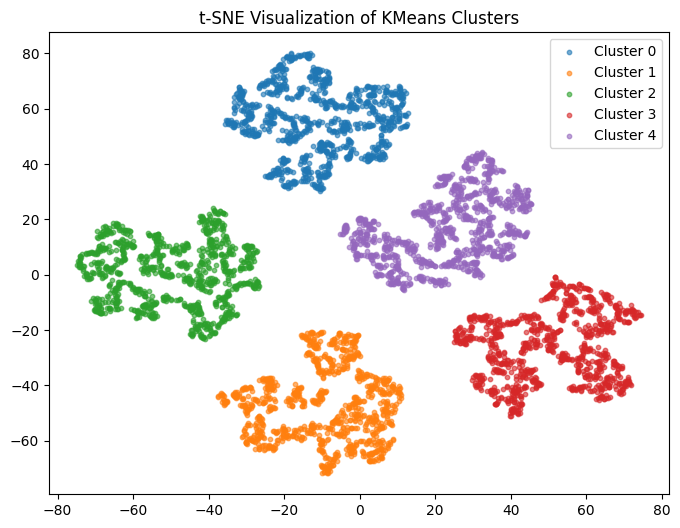

In [250]:
def kmeans_clustering(features, n_clusters=10):
    """Performs KMeans clustering on extracted features."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    predictions = kmeans.fit_predict(features)
    return kmeans, predictions

def visualize_tsne(features, predictions, n_clusters=10):
    """Performs t-SNE and visualizes clusters."""
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced_features = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    for i in range(n_clusters):
        plt.scatter(
            reduced_features[predictions == i, 0], reduced_features[predictions == i, 1], 
            label=f'Cluster {i}', alpha=0.6, s=10,
        )
    
    plt.legend()
    plt.title("t-SNE Visualization of KMeans Clusters")
    plt.show()

def main(data, labels, n_clusters=10, device="cuda"):
    kmeans, predictions = kmeans_clustering(data, n_clusters)
    visualize_tsne(data, predictions, n_clusters)
    

main(data, labels, n_clusters=5)

In [251]:
# create dataset
class ClusteredDataset(Dataset):
    def __init__(self, num_clusters=cluster_number, data_spread=data_spread, points_per_cluster=1000, cluster_std=0.05, seed=42):
        np.random.seed(seed)
        
        # Generate cluster centers close to each other
        base_center = np.array([0, 0])
        self.cluster_centers = [base_center + np.random.uniform(-data_spread,data_spread, size=2) for _ in range(num_clusters)]
        
        # Generate points around each cluster center
        data = []
        labels = []
        for i, center in enumerate(self.cluster_centers):
            cluster_points = np.random.normal(loc=center, scale=cluster_std, size=(points_per_cluster, 2))
            data.append(cluster_points)
            labels.extend([i] * points_per_cluster)

        self.data = torch.tensor(np.vstack(data), dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Function to load the dataset
def load_dataset(batch_size=128):
    dataset = ClusteredDataset()
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), dataset

In [252]:
# simple linear model
import torch.nn as nn
class SimpleNN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=10, output_dim=7):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

In [253]:

def soft_assignments(encoded_features, cluster_centers, alpha=1):
    """
    Compute soft assingments q_ij as described in DEC paper (1)
    q_ij = (1+ ||z_i - \mu_j||^2/a)^(-(a+1)/2) / (sum_j'((1+ ||z_i - \mu_j'||^2/a)^(-(a+1)/2)))
    """
    norm_squared = torch.sum(
        (encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)) ** 2, 2
    )
    assignments = 1.0 / (1.0 + (norm_squared / alpha))
    assignments = assignments ** ((alpha + 1) / 2)
    return assignments / torch.sum(assignments, dim=1, keepdim=True)

def target_distribution(batch: torch.Tensor, exponent=exponent) -> torch.Tensor:
    """
    Compute the target distribution p_ij, given the batch (q_ij), as in 3.1.3 Equation 3 of
    Xie/Girshick/Farhadi; this is used the KL-divergence loss function.
    p_ij = (q_ij^2/f_j) / sum_j'(q_ij'^2/f_j')  f_j =sum_i(q_ij)

    :param batch: [batch size, number of clusters] Tensor of dtype float
    :return: [batch size, number of clusters] Tensor of dtype float
    """
    weight = (batch**exponent) / torch.sum(batch, 0)
    return (weight.t() / torch.sum(weight, 1)).t()


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2109126/3117527646.py:2: SyntaxWarning: invalid escape sequence '\m'
  """


In [254]:
def trainer(model, dataloader, cluster_number=cluster_number, kmeans_init=10, exponent=exponent, lr=0.009, epochs=50, device=device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    kldiv_criterion = KLDivLoss(
        size_average=False
    )  # losses are summed for each minibatch

    model.to(device)
    model.train()

    cluster_centers_list = []
    features = []
    for batch, _ in dataloader:
        batch =batch.to(device)
        features.append(model(batch).detach().cpu())
    features = torch.cat(features).numpy()
    kmeans = KMeans(
        n_clusters=cluster_number, n_init=kmeans_init, random_state=seed
    )

    with torch.no_grad():
        predicted = kmeans.fit_predict(features)
    cluster_centers = torch.tensor(
        kmeans.cluster_centers_, dtype=torch.float, device=device
    )
    print(cluster_centers)
    with torch.no_grad():
        cluster_centers_list.append(cluster_centers.cpu().detach().numpy())

    for epoch in range(epochs):
        
        for inputs, _ in dataloader: 
            inputs = inputs.to(device)

            optimizer.zero_grad()        
            features = model(inputs)  

            output = soft_assignments(features.T, cluster_centers)
            target = target_distribution(output, exponent)
            loss = kldiv_criterion(output.log(), target)
            loss.backward()  

            numerator = torch.matmul(features.T,output).T.detach()
            denominator = torch.sum(output, dim=0, keepdim=True).T.detach()
            cluster_centers = numerator/denominator

            with torch.no_grad():
                cluster_centers_list.append(cluster_centers.cpu().detach().numpy())
            optimizer.step()  
            optimizer.zero_grad()   

        #print(f"Epoch {epoch}")

    print(cluster_centers)
    print("Training Complete!")
    model.eval()
    features = []    
    soft_assignments_list = []
    for batch, _ in dataloader:
        batch =batch.to(device)
        soft_assignments_list.append(soft_assignments(model(batch).T, cluster_centers))
        features.append(model(batch).detach().cpu())
    features = torch.cat(features).numpy()
    predictions = torch.cat(soft_assignments_list).max(1)[1].cpu().numpy()
    cluster_centers_np = np.array(cluster_centers_list)

    print('features: ', features.shape)
    print('predictions: ', predictions.shape)
    print('cluster centers ', cluster_centers_np.shape)
    return features, predictions, cluster_centers_np

In [255]:
dataloader, dataset = load_dataset(batch_size=32)
model = SimpleNN()
features, predictions, cluster_centers_list = trainer(model, dataloader, epochs=50)

/user/ninasophie.nellen/anaconda3/envs/my_env/lib/python3.12/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


tensor([[-0.3045,  0.7112, -0.4619, -1.2040,  0.3793, -1.3540,  0.1337],
        [ 0.1529,  0.5369, -0.0380, -0.6028,  0.1177, -0.8958, -0.0859],
        [-0.1693,  0.1423,  0.0164, -0.2540, -0.0511, -0.2447, -0.2201],
        [-0.7265,  0.6592, -0.0428, -1.4432,  0.0632, -1.0260, -0.0188],
        [ 0.5810,  0.5609,  0.1456, -0.3207, -0.0275, -0.6244, -0.3270]],
       device='cuda:5')
tensor([[ 0.0780,  0.3426,  0.2177, -0.5141, -0.3501, -0.3687, -0.2120],
        [ 0.0780,  0.3426,  0.2177, -0.5141, -0.3501, -0.3687, -0.2120],
        [ 0.0780,  0.3426,  0.2177, -0.5141, -0.3501, -0.3687, -0.2120],
        [ 0.0780,  0.3426,  0.2177, -0.5141, -0.3501, -0.3687, -0.2120],
        [ 0.0780,  0.3426,  0.2177, -0.5141, -0.3501, -0.3687, -0.2120]],
       device='cuda:5')
Training Complete!
features:  (5000, 7)
predictions:  (5000,)
cluster centers  (7851, 5, 7)


In [256]:
from sklearn.manifold import TSNE

def visualize_clusters(features, predictions, cluster_centers):

    n = features.shape[0]
    perplexity = n/100
    lr = n/12
    print(features.shape)
    print(cluster_centers.shape)

    plt.figure(figsize=(8,10), dpi=80)

    colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters
    color_map = {label: colors(i) for i, label in enumerate(range(cluster_number))}

    combined_data = np.vstack([features, cluster_centers])  # Stack features with centers

    # Apply t-SNE to combined data
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr, random_state=42)
    embedded_data = tsne.fit_transform(combined_data)  # Run on combined data

    embedded_points = embedded_data[:n]  # First part corresponds to data points
    embedded_centers = embedded_data[n:]  # Last part corresponds to cluster centers

    for value in range(cluster_number):
        cluster_mask = predictions == value
        print(f"Cluster {value}: Mask shape = {cluster_mask.shape}, Points = {cluster_mask.sum()}")
        
        plt.scatter(
            embedded_points[cluster_mask, 0],
            embedded_points[cluster_mask, 1],
            c=[color_map[value]],
            label=f'Cluster {value}',
            alpha=0.7,
            s=1,
        )
        plt.scatter(
            embedded_centers[value][0],
            embedded_centers[value][1],
            c=[color_map[value]],  # Mapped color
            marker='X',
            s=100,
            edgecolor='black',
            label='Cluster Center'
        )

    plt.title(f'clustered data')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Add legend automatically from the scatter plot
    plt.legend(title='Clusters', loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
    plt.show()

(5000, 7)
(5, 7)


/tmp/ipykernel_2109126/3876774867.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", cluster_number)  # Define colors for clusters


Cluster 0: Mask shape = (5000,), Points = 5000
Cluster 1: Mask shape = (5000,), Points = 0
Cluster 2: Mask shape = (5000,), Points = 0
Cluster 3: Mask shape = (5000,), Points = 0
Cluster 4: Mask shape = (5000,), Points = 0


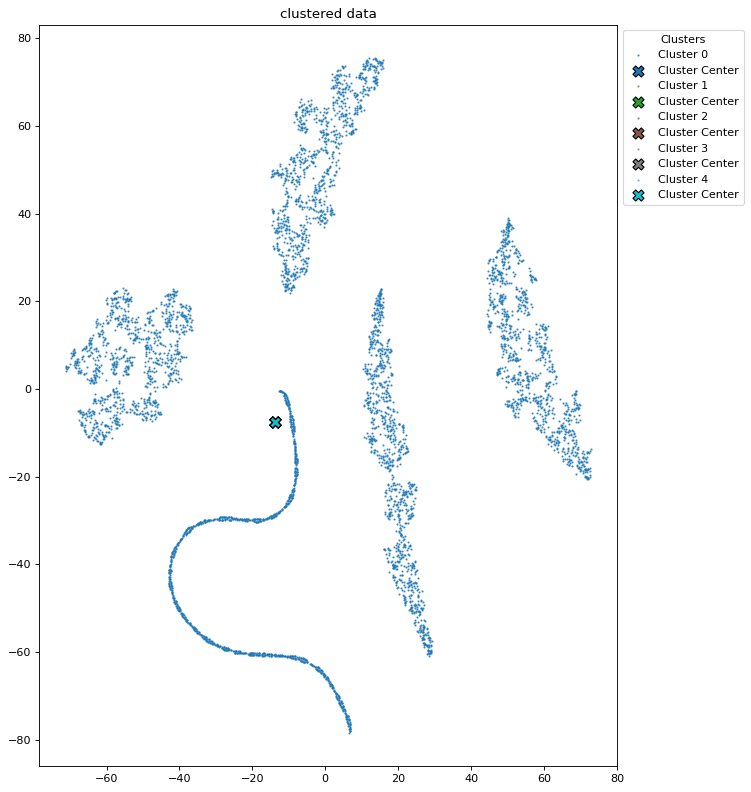

In [257]:
visualize_clusters(features, predictions, cluster_centers_list[-1])

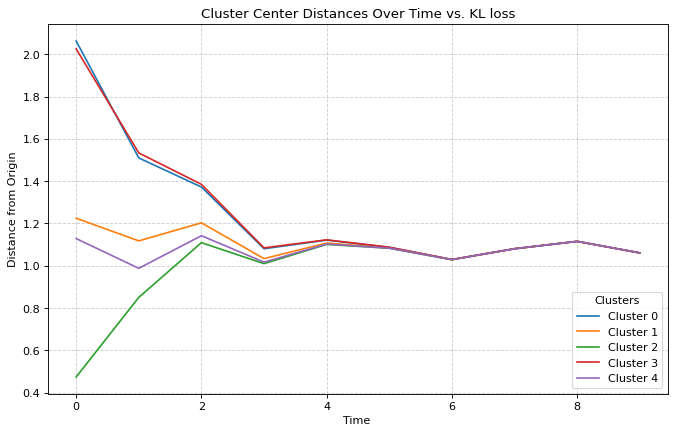

In [258]:
time = cluster_centers_list.shape[0]
end_time = 10
cluster_centers_distances=np.zeros((time, cluster_number)) 

for batch in range(time):
    cluster_centers_distances[batch][:] = np.linalg.norm(cluster_centers_list[batch],axis=1)

# Plot the distances of the cluster centers over time
plt.figure(figsize=(10, 6), dpi=80)


for cluster_idx in range(cluster_number):
    #if cluster_idx in unique_values:
    plt.plot(range(end_time), cluster_centers_distances[:end_time, cluster_idx], label=f'Cluster {cluster_idx}')

#plt.plot(range(end_time),kldiv_loss_batches[: end_time], label = 'kldiv_loss')
plt.xlabel('Time ')
plt.ylabel('Distance from Origin')
plt.title('Cluster Center Distances Over Time vs. KL loss')
plt.legend(title='Clusters', loc='lower right', frameon=True)
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()